In [1]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.cm as color
better_magma = color.magma
better_magma.set_bad('black',1.)
import matplotlib.colors as c

from prysm import (
    mathops, 
    conf,
)
from prysm.mathops import (
    _np,
    np,
    fft,
    interpolate,
    ndimage,
)
from prysm.coordinates import (
    make_xy_grid, 
    cart_to_polar,
)
from prysm.propagation import Wavefront as WF
from prysm.propagation import (
    focus_fixed_sampling,
    focus_fixed_sampling_backprop
)                              
from prysm.thinlens import (
    defocus_to_image_displacement,
    image_displacement_to_defocus,
)
from prysm.geometry import (
    offset_circle,
    circle,
    spider,
    gaussian,
)
from prysm.polynomials import (
    lstsq,
    noll_to_nm,
    zernike_nm,
    zernike_nm_seq,
    hopkins,
    sum_of_2d_modes,
    sum_of_2d_modes_backprop
)
mathops.set_backend_to_cupy()
# conf.config.precision = 32

from astropy.io import (
    fits,
    ascii,
)

from skimage.measure import centroid

import copy

from algos import FFPR2, PDPR, model, mean_squared_error, gain_invariant_error
import utils

from functools import partial

from lina.utils import TikhonovInverse

import config_um
import config_um_wcc
from Batoid4LOFT.LAZULI_STOP_mark11 import Lazuli_stop, readBulkMotion, readDeformation

from psd_utils import PSDUtils

from scipy.optimize import minimize

from scipy.interpolate import RegularGridInterpolator

from tqdm import tqdm

from psd_utils import PSDUtils

from model import telescope
# from algos import PDPR, OPD, ADPR
import utils

from functools import partial

from opt import F77LBFGSB, runN, RAdam
from IPython.display import clear_output

# logging stuff
import logging
psd_log = logging.getLogger('__psd_utils__')
psd_log.disabled = True

%reload_ext autoreload
%autoreload 2
%matplotlib inline

import toml

In [2]:
!nvidia-smi

Mon Apr 20 16:21:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.57.01              Driver Version: 565.57.01      CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100 80GB PCIe          On  |   00000000:25:00.0 Off |                    0 |
| N/A   31C    P0             64W /  300W |   69293MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## SETUP MODEL

In [3]:
optic_opd_data = utils.load_pickle('/home/derbyk/src/ffpr/data/opd_maps.pkl')

In [199]:
config = toml.load('/home/derbyk/src/ffpr/data/3m_off_axis_default.toml')

display(config)

{'general': {'wvl': 0.625,
  'bandwidth': 0.24,
  'n_wvls': 24,
  'npix_pupil': 512,
  'npix_focal': 256,
  'f_number': 15.0,
  'f_eff': 42047.0,
  'field_bias': 0.2,
  'jitter_rms': 0.01},
 'optics': {'m1': {'diam': 3065.0,
   'beam_size': 3065.0,
   'surface_rms': 10.0,
   'psd_b': 0.1,
   'psd_c': 2.85,
   'coating': 'NIST_1st_surface_Al.csv'},
  'm2': {'diam': 220.0,
   'beam_size': 168.5,
   'surface_rms': 5.0,
   'psd_b': 10.0,
   'psd_c': 2.65,
   'coating': 'NIST_1st_surface_Al.csv'},
  'm3': {'width': 380.0,
   'height': 220.0,
   'beam_size': 96.4,
   'surface_rms': 5.0,
   'psd_b': 10.0,
   'psd_c': 2.65,
   'coating': 'NIST_1st_surface_Al.csv'},
  'm4': {'diam': 80.0,
   'beam_size': 72.6,
   'surface_rms': 5.0,
   'psd_b': 10.0,
   'psd_c': 2.65,
   'coating': 'NIST_1st_surface_Al.csv'}},
 'detector': {'t_exp': 60,
  'gain': 120,
  'dx_focal': 3.76,
  'qe': 'ZWO_ASI6200MM_Pro_QE_curve.csv',
  'dark_current': 'ZWO_ASI6200MM_Pro_Dark_Current_vs_Sensor_Temperature.csv',
  'ga

In [200]:
sys = telescope(config=config, optic_opd_data=optic_opd_data)

In [201]:
# detector_data = utils.load_pickle('/home/derbyk/src/ffpr/data/detector_data.pkl')
# platescale = 4.486 # arcsec/mm

# w = 36 * platescale / 60
# h = 24 * platescale / 60
# w_offset = w / 2
# h_offset = h / 2

# positions = [(data['xy'][0] + w_offset, data['xy'][1] + h_offset) for data in detector_data]
# mags = (np.ones(len(positions)) * 18).tolist()

# sys.set_source_parameters(magnitudes=mags, positions=positions)

images = sys.snap(stacked_frames=1)

dark = sys.get_dark(stacked_frames=1)

for im in images:
    print(im.max() / dark.std())

588.1500894532584
445.3012587879164
613.4266772858518
539.7634784594368
720.1660967617747
296.24160939799435
516.2201423639356


## PSFS

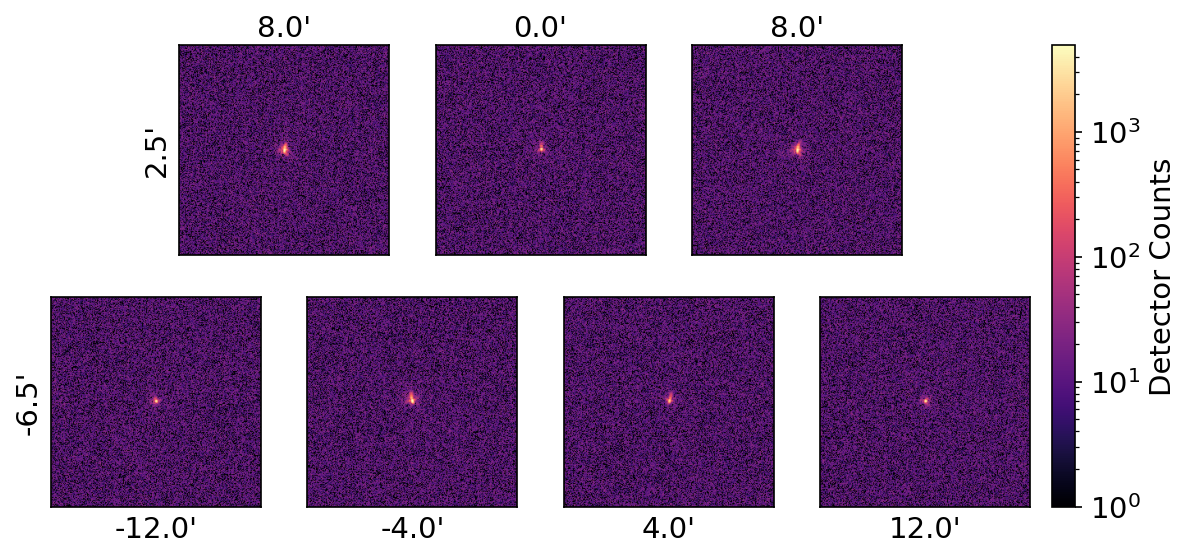

In [206]:
pupil = sys.pupil
fields = [(sys.cfg['sources'][src]['position_x'], sys.cfg['sources'][src]['position_y']) for src in sys.cfg['sources']]

utils.plot_psfs_7(psfs=images, fields=fields)

## WFES

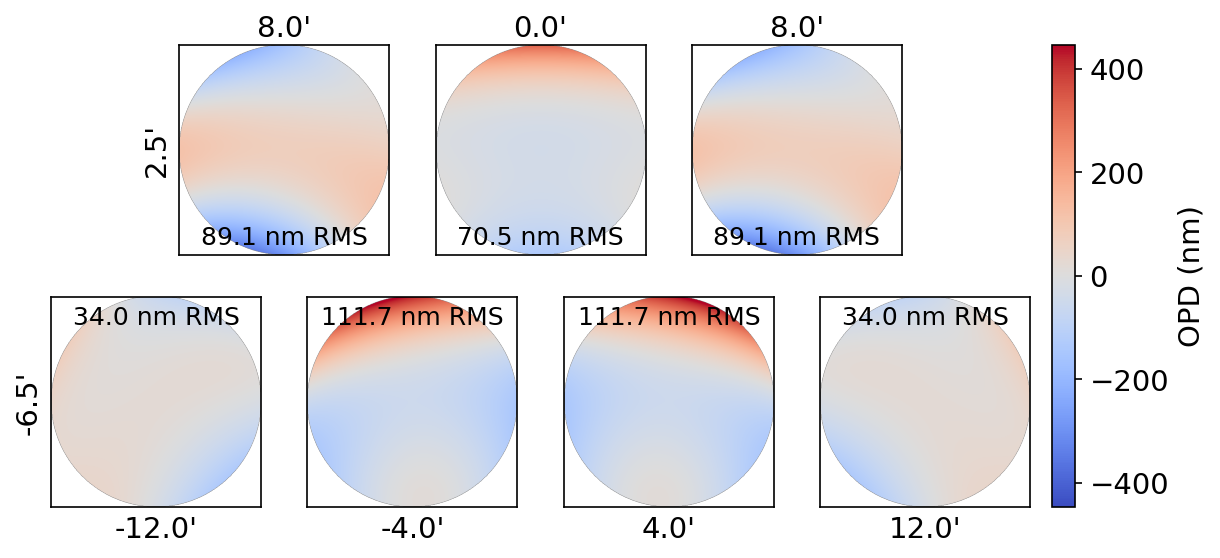

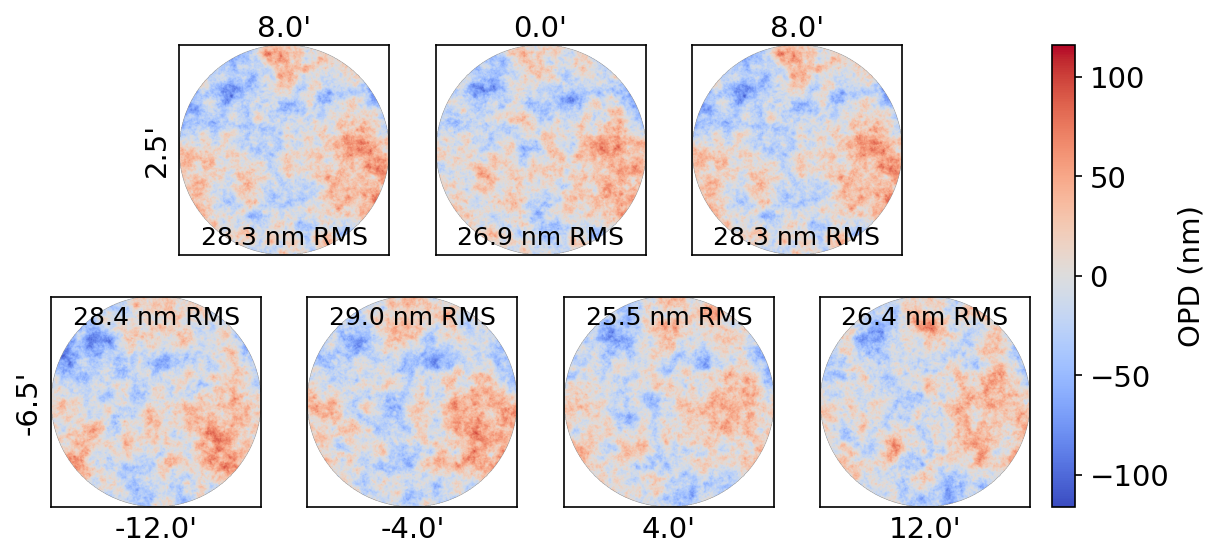

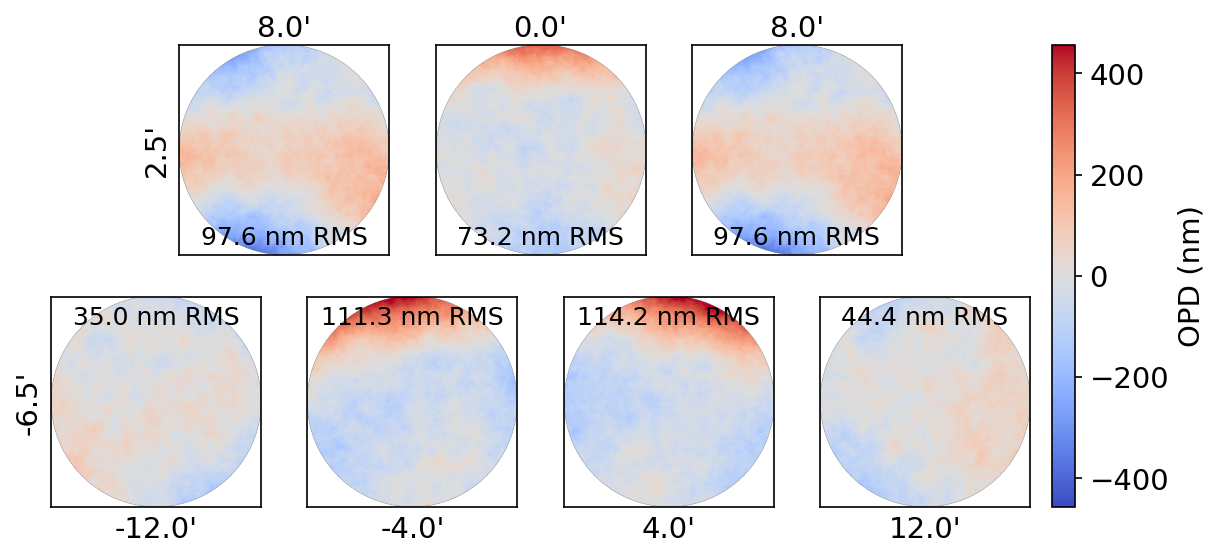

In [207]:
opds_fields = copy.deepcopy(sys.opds_field)
opds_optics = copy.deepcopy(sys.opds_optics)
opds_truths = [opd_field + opd_optics for (opd_field, opd_optics) in zip(opds_fields, opds_optics)]

opds_fields_nominal = opds_fields

utils.plot_opds_7(opds=opds_fields, pupil=pupil, fields=fields)
utils.plot_opds_7(opds=opds_optics, pupil=pupil, fields=fields)
utils.plot_opds_7(opds=opds_truths, pupil=pupil, fields=fields)

## FIELD DEPENDENT ABERRATIONS

In [9]:
raytrace = Lazuli_stop()

# zernike basis (excluding piston) up to Z37
x, y = make_xy_grid(sys.pupil.shape[0], dx=sys.dx_pup)
r, t = cart_to_polar(x, y)
nms = [noll_to_nm(i) for i in range(2, 37)]
zernikes = list(zernike_nm_seq(nms, r, t, norm=True))
zernikes = [z / np.max(np.abs(z)) for z in zernikes]

# indices for the zernikes which exhibit field dependence that changes with alignment: defocus, coma, astig, trefoil, spherical
# THESE DO NOT CORRESPOND TO NOLL INDICES
inds = [i + 2 for i in range(8)]

# field positions to evaluate
fields_x = np.linspace(-16.2, 16.2, 33) / 60 # +/- 16.2 arcmin in x
fields_y = np.linspace(-4.8, 4.8, 11) / 60  # +/- 4.8 arcmin in y

# initialize array to hold coeffs for field-dependent zernikes at nominal alignment
field_coeffs_nom = np.zeros((len(inds), len(fields_x), len(fields_y)))

# loop through fields
for i, field_x in enumerate(fields_x):
    for j, field_y in enumerate(fields_y):
        
        # get raytrace OPD at field point
        ray_data = raytrace.get_OPD(fieldX=field_x.get(), fieldY=field_y.get(), npx=sys.pupil.shape[0])
        opd = np.array(ray_data['wavefront'].array.data * ~ray_data['wavefront'].array.mask) * sys.wvl0 * 1e3
        opd[~sys.pupil] = np.nan

        # decompose
        field_coeffs_nom[:, i, j] = lstsq(np.array(zernikes), opd)[inds]

# create interpolators for field-dependent zernikes
field_interps_nom = [interpolate.RegularGridInterpolator((fields_x, fields_y), field_coeffs_nom[i, :, :], method='cubic') for i in range(field_coeffs_nom.shape[0])]

# show field dependence for field-dependent zernikes
plt.figure(figsize=(15, 12))
for i in range(field_coeffs_nom.shape[0]):
    plt.subplot(4, 2, i + 1)
    plt.title(f'Z{i + 4:.0f}')
    plt.imshow(field_coeffs_nom[i, :, :].get().T, interpolation='bicubic', extent=[-16.2, 16.2, -4.8, 4.8])
    plt.xlabel('Arcmin')
    plt.colorbar(fraction=0.016, pad=0.04, label='nm')

AttributeError: 'telescope' object has no attribute 'dx_pup'

## MISALIGN

In [ ]:
# create zernike basis 
x, y = make_xy_grid(shape=512, diameter=2)
r_norm, t = cart_to_polar(x, y)
nms = [noll_to_nm(i) for i in range(2, 11)]
zernikes = list(zernike_nm_seq(nms, r_norm, t, norm=True))

# for some reason, how the basis is normalized REALLY matters
# having everything normalized to unit peak-to-valley works best
zernikes = [z - np.min(z) for z in zernikes]
zernikes = [z / np.max(np.abs(z)) for z in zernikes]

2.4240684055476802e-05

In [54]:
dec_range = 50e-6
tilt_range = 2.424e-5

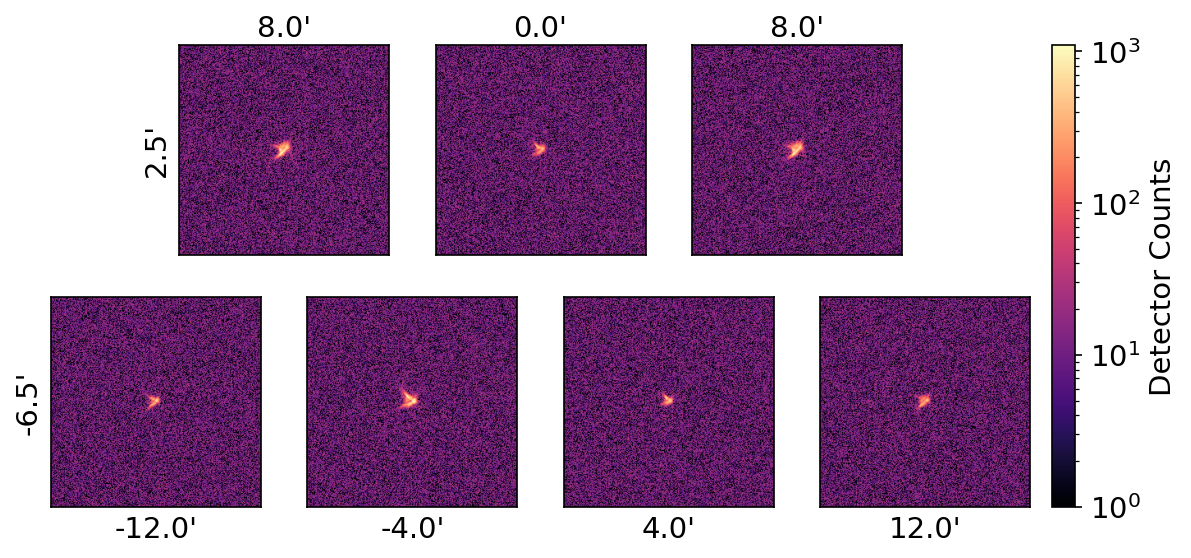

In [210]:
# M1_motion = {'user_motion' : {'x' : -286e-6, 'y' : 67e-6, 'z' : -162e-6, 'tip' : 2.6e-6, 'tilt' : -3.1e-6}}
# M2_motion = {'user_motion' : {'x' : -311e-6, 'y' : 44e-6, 'z' : -139e-6, 'tip' : 7.3e-6, 'tilt' : -20e-6}}
# M1_motion = {'user_motion' : {'x' : -286e-6, 'y' : 67e-6, 'z' : -162e-6, 'tip' : 6e-6, 'tilt' : -21e-6}}
# M2_motion = {'user_motion' : {'x' : -311e-6, 'y' : 44e-6, 'z' : -139e-6, 'tip' : 73e-6, 'tilt' : -81e-6}}
# M3_motion = {'user_motion' : {'x' : 0, 'y' : 0, 'z' : 0, 'tip' : 0, 'tilt' : 0}}
# M4_motion = {'user_motion' : {'x' : 0, 'y' : 0, 'z' : 0, 'tip' : 0, 'tilt' : 0}}

M1_motion = {'user_motion' : {'x' : 0, 'y' : 0, 'z' : 0, 'tip' : 0, 'tilt' : 0}}
# M2_motion = {'user_motion' : {'x' : 0, 'y' : 0, 'z' : 0, 'tip' : 0, 'tilt' : 0}}

# M1_motion = {'user_motion' : {'x' : _np.random.uniform(low=-dec_range, high=dec_range),
#                               'y' : _np.random.uniform(low=-dec_range, high=dec_range),
#                               'z' : _np.random.uniform(low=-1e-6, high=1e-6),
#                               'tip' : _np.random.uniform(low=-tilt_range, high=tilt_range), 
#                               'tilt' : _np.random.uniform(low=-tilt_range, high=tilt_range)}}
M2_motion = {'user_motion' : {'x' : _np.random.uniform(low=-dec_range, high=dec_range),
                              'y' : _np.random.uniform(low=-dec_range, high=dec_range),
                              'z' : _np.random.uniform(low=-1e-6, high=1e-6),
                              'tip' : _np.random.uniform(low=-tilt_range, high=tilt_range), 
                              'tilt' : _np.random.uniform(low=-tilt_range, high=tilt_range)}}
M3_motion = {'user_motion' : {'x' : _np.random.uniform(low=-dec_range, high=dec_range),
                              'y' : _np.random.uniform(low=-dec_range, high=dec_range),
                              'z' : _np.random.uniform(low=-1e-6, high=1e-6),
                              'tip' : _np.random.uniform(low=-tilt_range, high=tilt_range), 
                              'tilt' : _np.random.uniform(low=-tilt_range, high=tilt_range)}}
M4_motion = {'user_motion' : {'x' : _np.random.uniform(low=-dec_range, high=dec_range),
                              'y' : _np.random.uniform(low=-dec_range, high=dec_range),
                              'z' : _np.random.uniform(low=-1e-6, high=1e-6),
                              'tip' : _np.random.uniform(low=-tilt_range, high=tilt_range), 
                              'tilt' : _np.random.uniform(low=-tilt_range, high=tilt_range)}}
                              

sys.move_optics(M1_motion=M1_motion, M2_motion=M2_motion, M3_motion=M3_motion, M4_motion=M4_motion)

images = sys.snap(stacked_frames=1)

utils.plot_psfs_7(psfs=images, fields=fields)

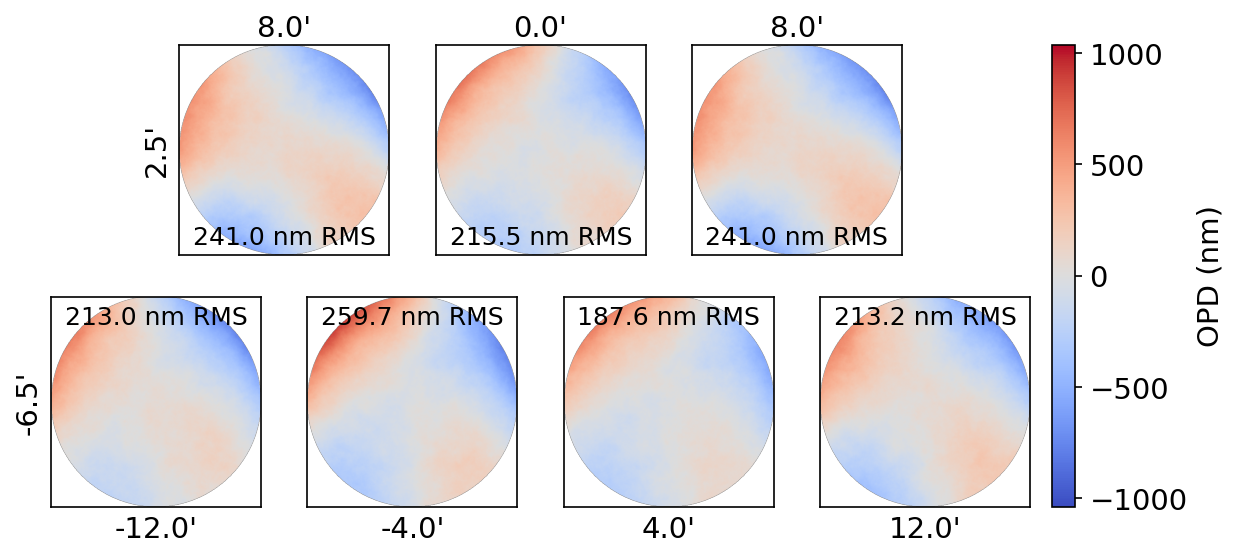

In [211]:
opds_fields = copy.deepcopy(sys.opds_field)
opds_optics = copy.deepcopy(sys.opds_optics)
opds_truths = [opd_field + opd_optics for (opd_field, opd_optics) in zip(opds_fields, opds_optics)]

utils.plot_opds_7(opds=opds_truths, pupil=pupil, fields=fields)

## FFPR

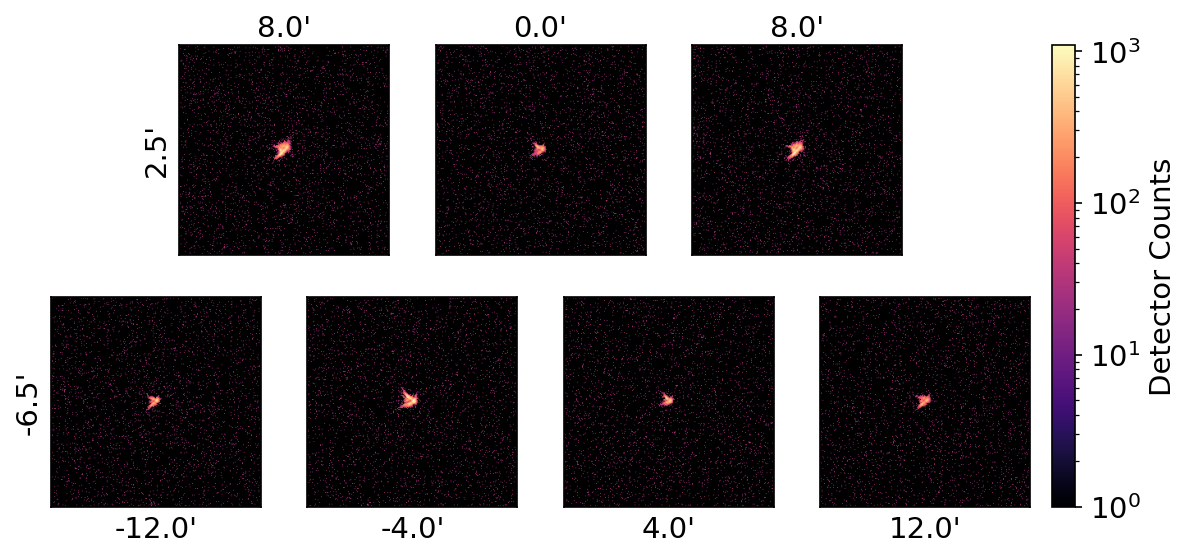

In [229]:
dark = sys.get_dark(stacked_frames=1)
images = [im - dark for im in sys.snap(stacked_frames=1)]

fields = [(sys.cfg['sources'][src]['position_x'], sys.cfg['sources'][src]['position_y']) for src in sys.cfg['sources']]

snr_thresh = 3
noise_lvl = dark.std()

filtered_images = []

for im in images:
    mask = im > noise_lvl * snr_thresh
    filtered_images.append(im * mask)

utils.plot_psfs_7(psfs=filtered_images, fields=fields)

In [230]:
efl = sys.cfg['general']['f_eff']
pupil_dx = sys.cfg['optics']['m1']['diam'] / sys.cfg['general']['npix_pupil']
focal_dx = sys.cfg['detector']['dx_focal']

opt = FFPR2(wvls=sys.wvls.tolist(), amp=sys.pupil, max_zernike=11, fields=fields, divs=opds_fields_nominal, efl=efl, 
            psfs=filtered_images, pupil_dx=pupil_dx, focal_dx=focal_dx, error=gain_invariant_error, jitter_kernel=sys.jitter_kernel)

In [ ]:
# fg = partial(opt.fg, opt_param='coeffs', opt_weights=None)

# # x0 = np.zeros(len(opt.coeffs)).get()
# x0 = np.concatenate((opt.field_terms, opt.coeffs), axis=0).get() # opt.coeffs.get()

# result = minimize(fg, x0=x0, jac=True, method='L-BFGS-B', 
#                   options={'maxls' : 10, 'ftol' : 1e-20, 'gtol' : 1e-10, 'disp' : 0, 'maxiter' : 75})


# fg = partial(opt.fg, opt_param='map', opt_weights=None)

# # x0 = np.zeros_like(opt.PDPR_list[0].map).ravel().get()
# x0 = opt.PDPR_list[0].map.ravel().get()

# result = minimize(fg, x0=x0, jac=True, method='L-BFGS-B', 
#                   options={'maxls' : 10, 'ftol' : 1e-20, 'gtol' : 1e-10, 'disp' : 0, 'maxiter' : 25})

In [231]:
max_bing_bong = 5
iter_per_bing_bong = 20
iter_per_psf = 10

frac = 1e-1
thresh = 1e-1
count = 1
bing = 1.
bong = 1.

while True: 

    # fg = partial(opt.fg, opt_param='all', opt_weights=None)
    # x0 = np.concatenate((opt.field_terms, opt.coeffs), axis=0).get() 
    # lbfgsb = F77LBFGSB(fg=fg, x0=x0, memory=10, lower_bounds=None, upper_bounds=None)

    fg = partial(opt.fg, opt_param='common', opt_weights=None)
    x0 = opt.coeffs.get()
    lbfgsb = F77LBFGSB(fg=fg, x0=x0, memory=10, lower_bounds=None, upper_bounds=None)

    for _, _, _ in lbfgsb.run_to(N=iter_per_bing_bong):
        clear_output()

    # for _ in range(iter_per_bing_bong):
    #     clear_output()
    #     x, f, g = lbfgsb.step()
    # clear_output()

    bing = float(opt.costs[-1])

    if (np.abs(bong - bing) <= (frac * bong)) and bing < thresh:
        break
    
    fg = partial(opt.fg, opt_param='all', opt_weights=None)
    x0 = np.concatenate((opt.field_terms, opt.coeffs), axis=0).get() 
    lbfgsb = F77LBFGSB(fg=fg, x0=x0, memory=10, lower_bounds=None, upper_bounds=None)

    # fg = partial(opt.fg, opt_param='common', opt_weights=None)
    # x0 = opt.coeffs.get()
    # lbfgsb = F77LBFGSB(fg=fg, x0=x0, memory=10, lower_bounds=None, upper_bounds=None)

    for _, _, _ in lbfgsb.run_to(N=iter_per_bing_bong):
        clear_output()

    # for _ in range(iter_per_bing_bong):
    #     clear_output()
    #     x, f, g = lbfgsb.step()
    # clear_output()

    bong = float(opt.costs[-1])

    if (np.abs(bing - bong) <= (frac * bing)) and bong < thresh:
        break

    if count == max_bing_bong:
        break

    count += 1

for pdpr in opt.PDPR_list:
    fg = partial(pdpr.fg, opt_param='coeffs', opt_weights=None)
    x0 = pdpr.coeffs.get()

    lbfgsb = F77LBFGSB(fg=fg, x0=x0, memory=10, lower_bounds=None, upper_bounds=None)

    for _, _, _ in lbfgsb.run_to(N=iter_per_psf):
        clear_output()

    # for _ in range(iter_per_psf):
    #     clear_output()
    #     x, f, g = lbfgsb.step()
    # clear_output()

# for pdpr in opt.PDPR_list:
#     fg = partial(pdpr.fg, opt_param='map', opt_weights=None)
#     x0 = pdpr.map.ravel().get()

#     lbfgsb = F77LBFGSB(fg=fg, x0=x0, memory=10, lower_bounds=None, upper_bounds=None)

#     for _, _, _ in lbfgsb.run_to(N=iter_per_psf):
#         clear_output()

#     # for _ in range(iter_per_psf):
#     #     clear_output()
#     #     x, f, g = lbfgsb.step()
#     # clear_output()

/tmp/ipykernel_1562638/99148464.py:12: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim([0, 1])


(0.09180655298113004, 1)

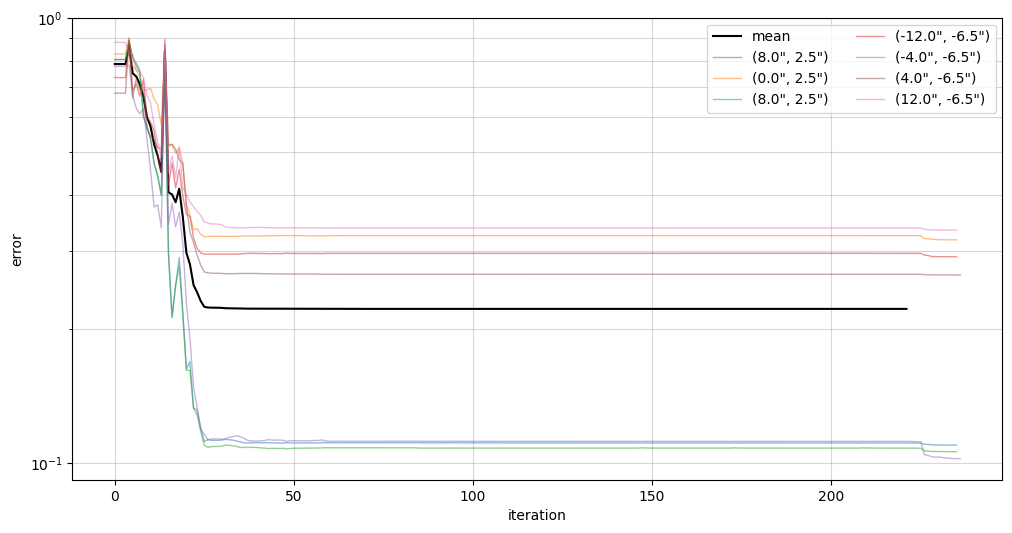

In [232]:
plt.figure(figsize=(12, 6))
plt.semilogy(np.array(opt.costs).get(), label='mean', color='k', linewidth=1.5)
plt.xlabel('iteration')
plt.ylabel('error')
plt.grid(which='both', alpha=0.5)

for PDPR, field in zip(opt.PDPR_list, fields):
    plt.semilogy(np.array(PDPR.costs).get(), label=f'({field[0]:.1f}", {field[1]:.1f}")', alpha=0.5, linewidth=1)

plt.legend(ncols=2)
# plt.xlim([0, len(opt.costs)])
plt.ylim([0, 1])

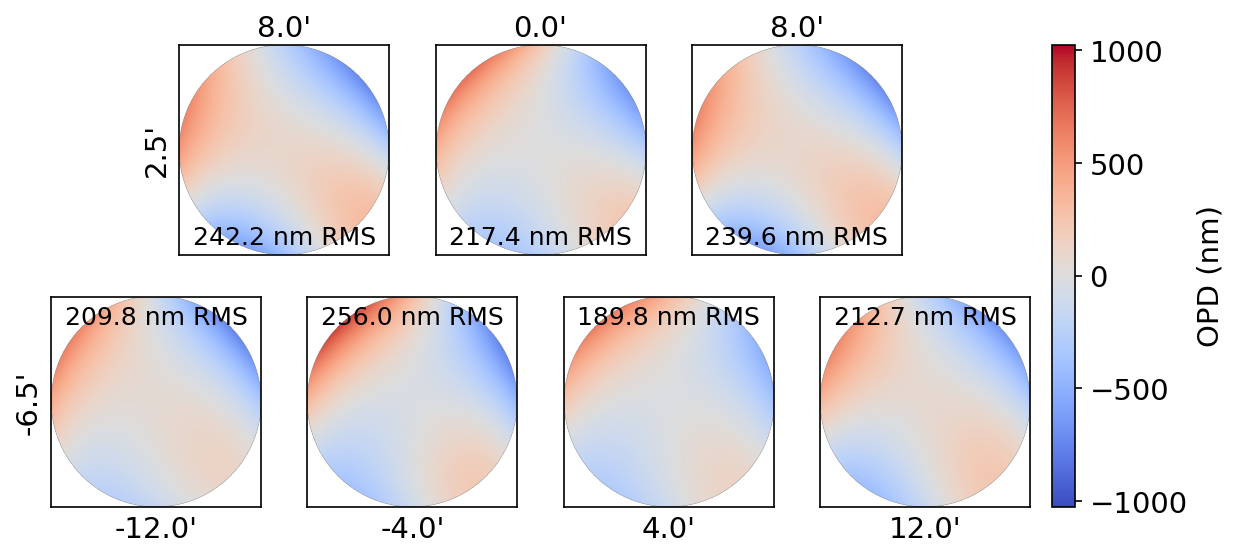

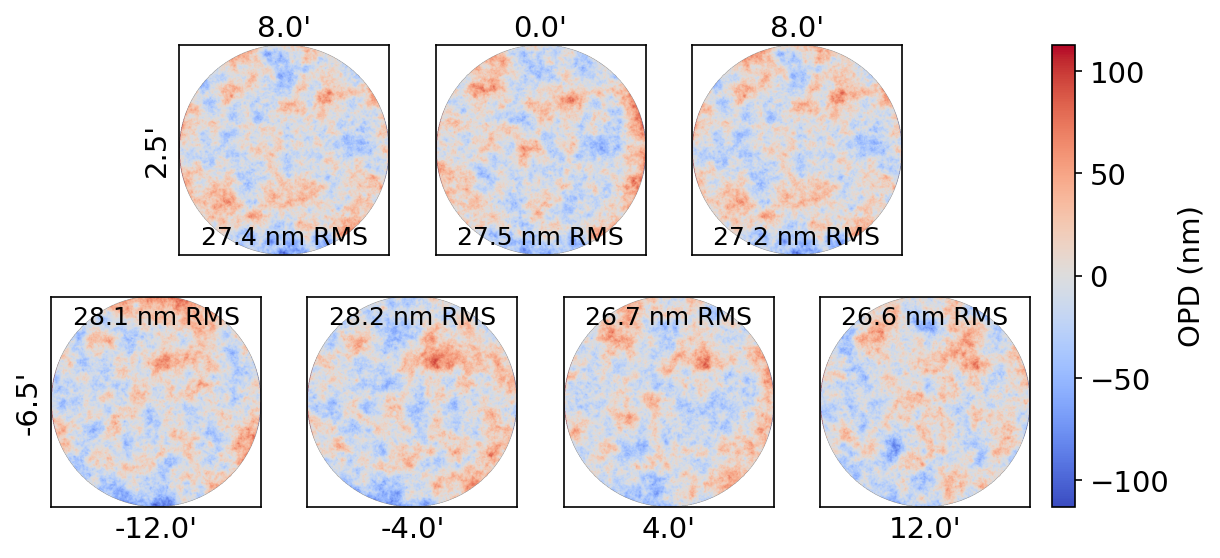

In [233]:
opds_estimates = [PDPR.models[0].opd + PDPR.models[0].div for PDPR in opt.PDPR_list]
opds_residuals = [estimate - truth for estimate, truth, optics in zip(opds_estimates, opds_truths, opds_optics)]

utils.plot_opds_7(opds=opds_estimates, pupil=pupil, fields=fields)
utils.plot_opds_7(opds=opds_residuals, pupil=pupil, fields=fields)

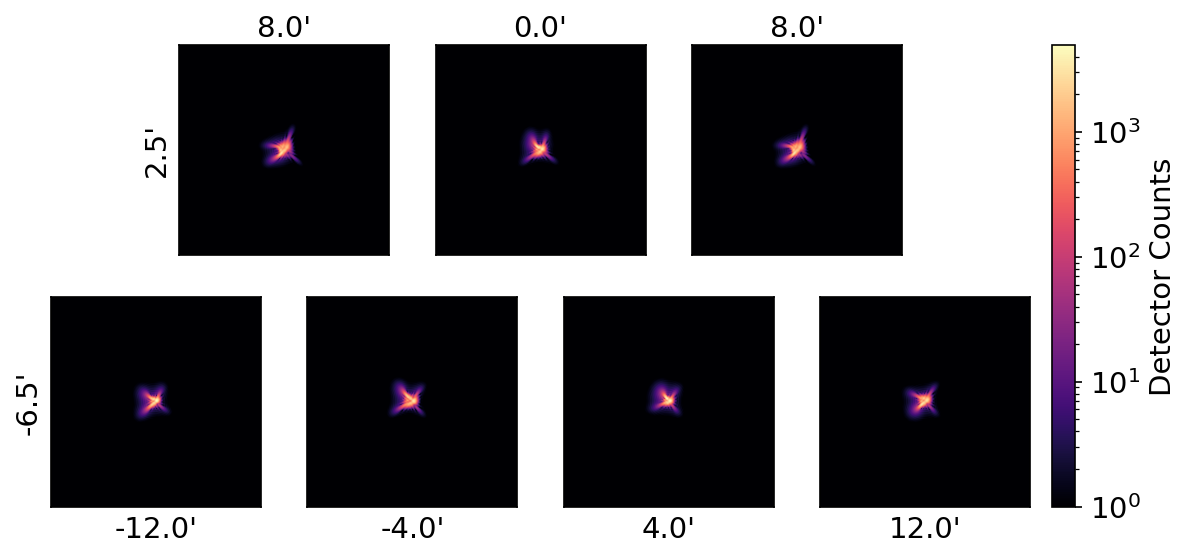

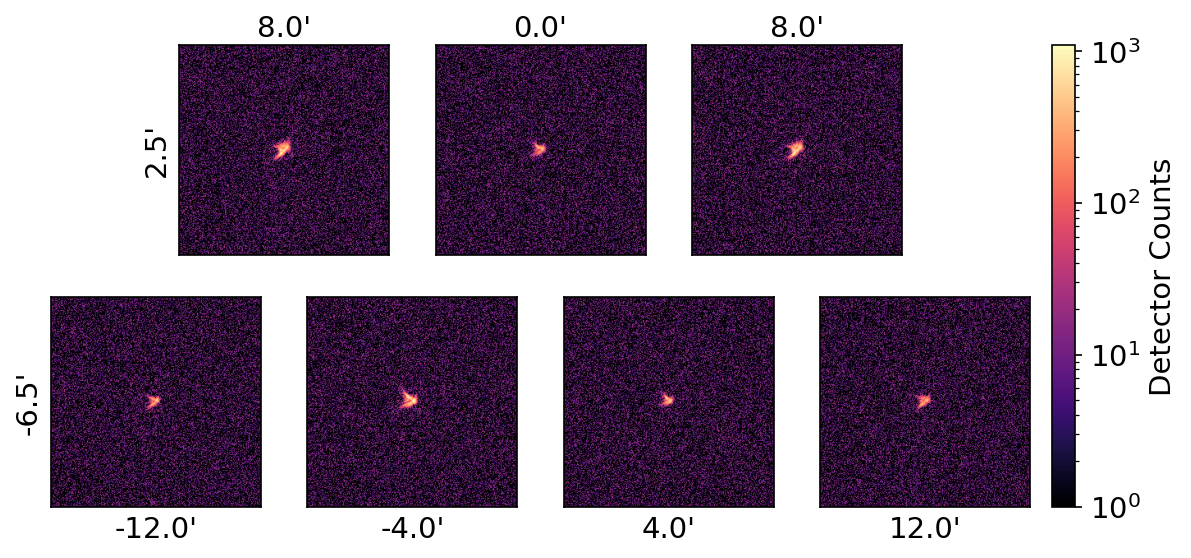

In [234]:
psf_estimates = [PDPR.models[0].I for PDPR in opt.PDPR_list]

psf_truths = [PDPR.models[0].psf for PDPR in opt.PDPR_list]

utils.plot_psfs_7(psfs=psf_estimates, fields=fields)

utils.plot_psfs_7(psfs=images, fields=fields)